In [32]:
!pip install -q spacy transformers accelerate scikit-learn pandas numpy matplotlib

!python -m spacy download pt_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 3.2 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [33]:
import pandas as pd
import numpy as np
import spacy
import random

from transformers import AutoTokenizer, AutoModel
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import torch

In [34]:
nlp = spacy.load("pt_core_news_lg")

In [35]:
import random

sujeitos = [
    "A inteligência artificial",
    "O machine learning",
    "O deep learning",
    "As redes neurais",
    "O processamento de linguagem natural",
    "A visão computacional",
    "Os algoritmos de IA",
    "Os modelos generativos",
    "Os sistemas especialistas",
    "Os modelos de linguagem"
]

verbos = [
    "auxiliam",
    "transformam",
    "automatizam",
    "otimizam",
    "melhoram",
    "analisam",
    "classificam",
    "identificam",
    "processam",
    "detectam"
]

objetos = [
    "diagnósticos médicos",
    "análise de imagens",
    "reconhecimento facial",
    "tradução automática",
    "previsões financeiras",
    "análise de sentimentos",
    "chatbots inteligentes",
    "detecção de fraudes",
    "veículos autônomos",
    "sistemas de recomendação"
]

complementos = [
    "em hospitais.",
    "na indústria.",
    "em empresas de tecnologia.",
    "em universidades.",
    "em pesquisas científicas.",
    "no setor financeiro.",
    "em plataformas digitais.",
    "na educação.",
    "em sistemas modernos.",
    "em aplicações comerciais."
]

frases = []

for _ in range(5000):
    frase = (
        f"{random.choice(sujeitos)} "
        f"{random.choice(verbos)} "
        f"{random.choice(objetos)} "
        f"{random.choice(complementos)}"
    )

    frases.append(frase)

df = pd.DataFrame({"texto": frases})

print(df.shape)
print(df["texto"].nunique())
df.head()

(5000, 1)
3925


,texto
0,A inteligência artificial classificam diagnóst...
1,O processamento de linguagem natural auxiliam ...
2,Os modelos de linguagem detectam previsões fin...
3,As redes neurais classificam análise de sentim...
4,O processamento de linguagem natural classific...


In [36]:
resultado = []

for texto in df["texto"]:
    doc = nlp(texto)

    for token in doc:
        resultado.append([
            token.text,
            token.pos_,
            token.tag_
        ])

df_pos = pd.DataFrame(
    resultado,
    columns=["Palavra", "Classe", "Tag"]
)

df_pos.head(20)

,Palavra,Classe,Tag
0,A,DET,DET
1,inteligência,NOUN,NOUN
2,artificial,ADJ,ADJ
3,classificam,VERB,VERB
4,diagnósticos,ADJ,ADJ
5,médicos,ADJ,ADJ
6,em,ADP,ADP
7,hospitais,NOUN,NOUN
8,.,PUNCT,PUNCT
9,O,DET,DET


In [37]:
entidades = []

for texto in df["texto"]:
    doc = nlp(texto)

    for ent in doc.ents:
        entidades.append([
            ent.text,
            ent.label_
        ])

df_entidades = pd.DataFrame(
    entidades,
    columns=["Entidade", "Tipo"]
)

df_entidades.head()

,Entidade,Tipo
0,deep learning,MISC
1,deep learning,MISC
2,deep learning,MISC
3,deep learning,ORG
4,deep learning,MISC


In [38]:
TRAIN_DATA = [
    (
        "O ChatGPT utiliza inteligência artificial.",
        {"entities": [(2, 9, "FERRAMENTA")]}
    ),
    (
        "O TensorFlow é usado em Machine Learning.",
        {"entities": [(2, 12, "FRAMEWORK")]}
    ),
    (
        "O BERT é um modelo de linguagem.",
        {"entities": [(2, 6, "MODELO")]}
    )
]

In [39]:
import spacy
from spacy.training import Example

nlp_ner = spacy.blank("pt")

ner = nlp_ner.add_pipe("ner")

ner.add_label("FERRAMENTA")
ner.add_label("FRAMEWORK")
ner.add_label("MODELO")

optimizer = nlp_ner.begin_training()

for i in range(20):

    random.shuffle(TRAIN_DATA)

    for texto, anotacoes in TRAIN_DATA:

        doc = nlp_ner.make_doc(texto)

        example = Example.from_dict(doc, anotacoes)

        nlp_ner.update([example], losses={})

print("Treinamento concluído.")

Treinamento concluído.


In [40]:
doc = nlp_ner(
    "O ChatGPT e o BERT são usados em inteligência artificial."
)

for ent in doc.ents:
    print(ent.text, ent.label_)

ChatGPT FERRAMENTA
BERT MODELO


In [41]:
modelo = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(modelo)

bert = AutoModel.from_pretrained(modelo)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [42]:
embeddings = []

for texto in df["texto"][:2000]:

    entrada = tokenizer(
        texto,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        saida = bert(**entrada)

    vetor = saida.last_hidden_state.mean(dim=1)

    embeddings.append(vetor.numpy()[0])

embeddings = np.array(embeddings)

print(embeddings.shape)

(2000, 768)


In [43]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(embeddings)

df_cluster = pd.DataFrame({
    "texto": df["texto"][:2000].values,
    "cluster": clusters
})

df_cluster.head()

,texto,cluster
0,A inteligência artificial classificam diagnóst...,0
1,O processamento de linguagem natural auxiliam ...,0
2,Os modelos de linguagem detectam previsões fin...,1
3,As redes neurais classificam análise de sentim...,1
4,O processamento de linguagem natural classific...,0


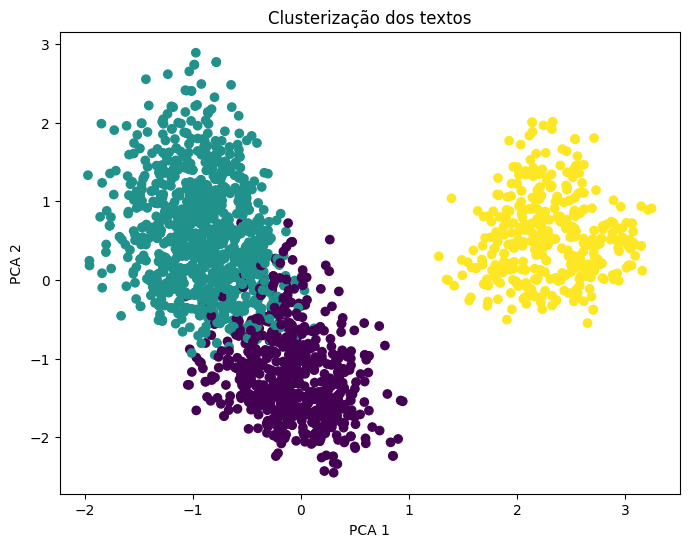

In [44]:
pca = PCA(n_components=2)

dados = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))

plt.scatter(
    dados[:,0],
    dados[:,1],
    c=clusters
)

plt.title("Clusterização dos textos")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [45]:
from sklearn.metrics import silhouette_score

resultados = []

for k in range(2,11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    grupos = modelo.fit_predict(embeddings)

    score = silhouette_score(
        embeddings,
        grupos
    )

    resultados.append([k, score])

df_scores = pd.DataFrame(
    resultados,
    columns=["K", "Silhouette"]
)

display(df_scores)

melhor_k = df_scores.loc[
    df_scores["Silhouette"].idxmax(),
    "K"
]

print("Melhor k:", melhor_k)

,K,Silhouette
0,2,0.129788
1,3,0.124046
2,4,0.116525
3,5,0.123454
4,6,0.130059
5,7,0.134564
6,8,0.138903
7,9,0.133782
8,10,0.137623


Melhor k: 8


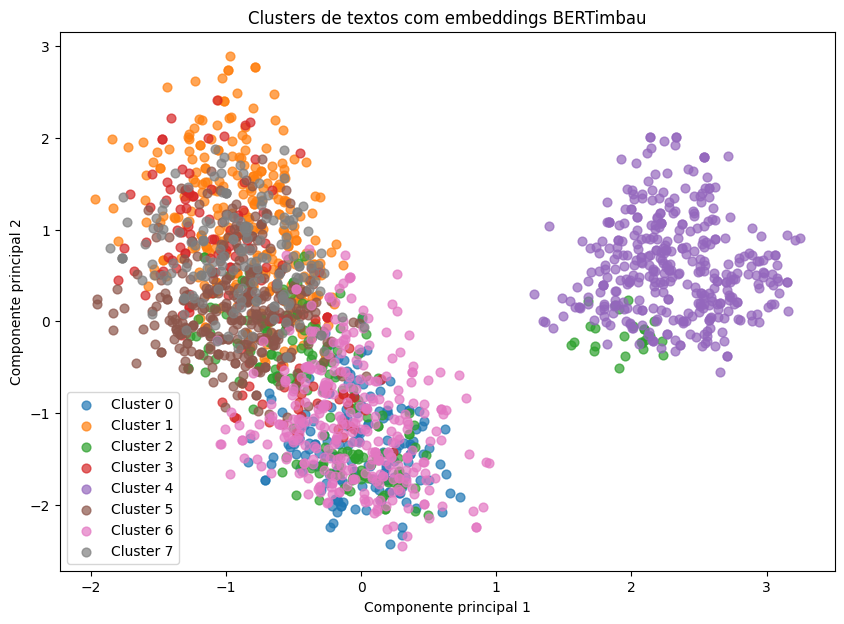

In [46]:
kmeans = KMeans(
    n_clusters=int(melhor_k),
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(embeddings)

pca = PCA(n_components=2)

dados = pca.fit_transform(embeddings)

plt.figure(figsize=(10,7))

for cluster in np.unique(clusters):

    plt.scatter(
        dados[clusters == cluster,0],
        dados[clusters == cluster,1],
        s=40,
        alpha=0.7,
        label=f"Cluster {cluster}"
    )

plt.title(
    "Clusters de textos com embeddings BERTimbau"
)

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")

plt.legend()

plt.show()

In [47]:
df_pos.to_csv("pos_tagging.csv", index=False)

df_entidades.to_csv("entidades.csv", index=False)

df_cluster.to_csv("clusters.csv", index=False)